# Chapter 9 — Eigenvalues: theory and vector iterations

**Numerical Linear Algebra: Theory, Algorithms, and Computation**

**Abdallah Alsammani, Ph.D.**  
Department of Mathematical Sciences & Data Science  
Delaware State University

Lecture notes: <https://aalsammani.github.io/numerical-linear-algebra/>  
Notes for this chapter: <https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html>  
Repository: <https://github.com/aalsammani/Numerical-Linear-Algebra-Notebooks>

This notebook is the computational laboratory of the chapter; the theory,
proofs and exercises are in the lecture notes, to which the links below
point. References such as Trefethen and Bau (1997) are listed in the
[bibliography of the notes](https://aalsammani.github.io/numerical-linear-algebra/back/bibliography.html). Version
1.0, September 2026.

---

This notebook accompanies [Chapter 9](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09) of the notes. It checks
the structural and perturbation theory of the chapter numerically, and it
implements and measures the vector iterations: power iteration, inverse
iteration, Rayleigh quotient iteration and simultaneous iteration.

**Learning objectives.** After working through this lab you should be able to

1. verify computed eigendecompositions through backward errors, and recognize
   the numerical signature of a defective matrix;
2. explain with an experiment why the characteristic polynomial is a poor
   route to eigenvalues, and read eigenvalues correctly from a real Schur form;
3. use Gershgorin discs, the Bauer--Fike theorem and eigenvalue condition
   numbers $1/|y^*x|$ to predict how eigenvalues move under perturbations;
4. implement power, inverse and Rayleigh quotient iteration with residual-based
   stopping criteria, and compare their measured convergence with the theory,
   including the order of convergence;
5. implement simultaneous iteration and relate it to the QR algorithm of
   [Chapter 10](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10).

Notation: $u = 2^{-53}$ is the unit roundoff. Perturbation sizes are called
$\delta$. Run the cells in order from a fresh kernel.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.linalg as sla

rng = np.random.default_rng(20260909)
u = np.finfo(float).eps / 2          # unit roundoff of IEEE double precision, 2**-53
plt.rcParams.update({"figure.figsize": (6.4, 4.0), "axes.grid": True, "grid.alpha": 0.3})
print(f"NumPy {np.__version__}, SciPy {scipy.__version__}; unit roundoff u = {u:.3e}")


def sin_angle(v, x):
    """Sine of the angle between the lines spanned by v and x (real or complex)."""
    v = v / np.linalg.norm(v)
    x = x / np.linalg.norm(x)
    return np.linalg.norm(v - x * np.vdot(x, v))


def tan_angle(v, x):
    """Tangent of the angle between the lines spanned by v and x."""
    v = v / np.linalg.norm(v)
    x = x / np.linalg.norm(x)
    return np.linalg.norm(v - x * np.vdot(x, v)) / abs(np.vdot(x, v))


def symmetric_with_eigenvalues(lam, rng):
    """Return (A, Q) with A = Q diag(lam) Q^T symmetric and Q a random orthogonal matrix."""
    n = len(lam)
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    A = (Q * lam) @ Q.T
    return (A + A.T) / 2, Q

NumPy 2.5.3, SciPy 1.18.1; unit roundoff u = 1.110e-16


## 1. Eigenpairs, backward errors, and a defective matrix

A computed eigendecomposition cannot be checked against the exact one, which
we do not know. What we can check is the backward error: LAPACK's symmetric
and nonsymmetric eigensolvers are backward stable, so the residual
$AX - X\Lambda$ of the computed factors is a modest multiple of $nu\|A\|$
(times $\|X\|$ when $X$ is not orthogonal).

In [2]:
n = 6
S = rng.standard_normal((n, n))
S = S + S.T                                   # symmetric
G = rng.standard_normal((n, n))               # general

lam_s, Q_s = np.linalg.eigh(S)
lam_g, X_g = np.linalg.eig(G)
res_s = np.linalg.norm(S @ Q_s - Q_s * lam_s, 2) / np.linalg.norm(S, 2)
orth_s = np.linalg.norm(Q_s.T @ Q_s - np.eye(n), 2)
res_g = np.linalg.norm(G @ X_g - X_g * lam_g, 2) / (np.linalg.norm(G, 2) * np.linalg.norm(X_g, 2))
print(f"symmetric: eigenvalues real = {np.isrealobj(lam_s)}, "
      f"||SQ - Q Lambda|| / ||S|| = {res_s:.1e}, ||Q^T Q - I|| = {orth_s:.1e}")
print(f"general:   {np.sum(np.abs(lam_g.imag) > 0)} of {n} eigenvalues non-real, "
      f"||GX - X Lambda|| / (||G|| ||X||) = {res_g:.1e}")
# Backward stability: residuals are O(n u) relative to the data; 100 n u leaves room for the constant.
assert res_s < 100 * n * u and orth_s < 100 * n * u and res_g < 100 * n * u

symmetric: eigenvalues real = True, ||SQ - Q Lambda|| / ||S|| = 7.6e-16, ||Q^T Q - I|| = 8.4e-16
general:   4 of 6 eigenvalues non-real, ||GX - X Lambda|| / (||G|| ||X||) = 1.1e-15


The non-real eigenvalues of a real matrix come in conjugate pairs. Now the
Jordan block $J_4(2)$ of [Example 9.1](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-exa-jordan-block), which has a single
eigenvector direction. `numpy.linalg.eig` still returns four "eigenvectors",
but they are numerically parallel: the matrix $X$ is singular to working
precision, so no diagonalization exists in any useful sense.

In [3]:
J4 = 2 * np.eye(4) + np.diag(np.ones(3), 1)
lam_J, X_J = np.linalg.eig(J4)
print("eigenvalues of J_4(2):", lam_J.real)
print(f"cond(X) = {np.linalg.cond(X_J):.1e}   (1/u = {1 / u:.1e})")
assert np.linalg.cond(X_J) > 1 / u            # numerically singular eigenvector matrix

delta = 1e-12
E = rng.standard_normal((4, 4))
E *= delta / np.linalg.norm(E, 2)
lam_JE = np.linalg.eigvals(J4 + E)
print(f"perturbation of norm {delta:.0e} moves the eigenvalue by up to {np.max(np.abs(lam_JE - 2)):.1e}"
      f"   (delta^(1/4) = {delta ** 0.25:.0e})")
# Pseudospectrum check (Proposition ch09-prop-pseudospectrum): every computed eigenvalue z of J+E is an
# exact eigenvalue of J + E + F with ||F|| = O(u ||J||), so sigma_min(zI - J) <= delta + O(u ||J||).
for z in lam_JE:
    smin = np.linalg.svd(z * np.eye(4) - J4, compute_uv=False)[-1]
    assert smin <= delta + 100 * u * np.linalg.norm(J4, 2)
assert np.max(np.abs(lam_JE - 2)) > 1e3 * delta  # far larger than the perturbation itself

eigenvalues of J_4(2): [2. 2. 2. 2.]
cond(X) = 3.2e+46   (1/u = 9.0e+15)
perturbation of norm 1e-12 moves the eigenvalue by up to 7.7e-04   (delta^(1/4) = 1e-03)


**Interpretation.** A perturbation of size $10^{-12}$ moves the fourfold
eigenvalue by roughly $10^{-3}$, in line with the $\delta^{1/n}$ behavior of
[Example 9.7](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-exa-jordan-perturbation). Every perturbed eigenvalue $z$ also
satisfies $\sigma_{\min}(zI - J) \le \delta$ up to rounding errors of order
$u\|J\|_2$, which is the characterization
of the pseudospectrum in [Proposition 9.3](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-prop-pseudospectrum).

## 2. The characteristic polynomial is the wrong route

We reproduce [Example 9.2](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-exa-wilkinson). `numpy.poly` forms the
coefficients of $\prod_{j=1}^{20}(z - j)$ in floating point and `numpy.roots`
computes the eigenvalues of the companion matrix. The first-order condition
number that measures the *absolute* change of the root $z = j$ caused by
relative changes of the coefficients is $\prod_i(j+i)/\prod_{i\ne j}|j-i|$;
multiplied by $u$ it predicts the absolute errors plotted below.

largest |imaginary part| of the computed roots: 0.0e+00
max error of the roots from the polynomial: 0.093 (at z = 14)
condition numbers of z = 14, 15: 7.55e+14, 7.55e+14; times u: 0.084
max error of eigvalsh on Q diag(1..20) Q^T: 1.1e-14


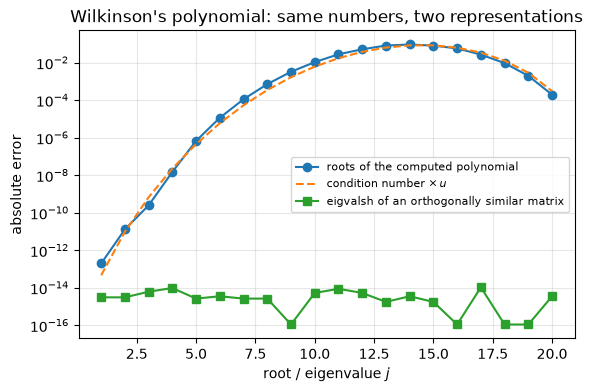

In [4]:
true_roots = np.arange(1, 21)
coeffs = np.poly(true_roots)
computed = np.roots(coeffs)
print(f"largest |imaginary part| of the computed roots: {np.max(np.abs(computed.imag)):.1e}")
computed = np.sort(computed.real)
err_poly = np.abs(computed - true_roots)
cond_root = np.array([np.prod([float(j + i) for i in range(1, 21)])
                      / np.prod([float(abs(j - i)) for i in range(1, 21) if i != j]) for j in true_roots])
print(f"max error of the roots from the polynomial: {err_poly.max():.3f} (at z = {true_roots[np.argmax(err_poly)]})")
print(f"condition numbers of z = 14, 15: {cond_root[13]:.2e}, {cond_root[14]:.2e}; times u: {cond_root[14] * u:.3f}")
assert np.isclose(cond_root[13], cond_root[14]) and round(cond_root[14] / 1e14, 1) == 7.6

A_w, _ = symmetric_with_eigenvalues(true_roots.astype(float), rng)
err_eig = np.abs(np.linalg.eigvalsh(A_w) - true_roots)
print(f"max error of eigvalsh on Q diag(1..20) Q^T: {err_eig.max():.1e}")
# Weyl + backward stability: errors <= ||E||_2 = O(n u ||A||_2) with ||A||_2 = 20 (forming A adds the same order).
assert err_eig.max() < 100 * 20 * u * 20
assert err_poly.max() > 1e8 * err_eig.max()

fig, ax = plt.subplots()
ax.semilogy(true_roots, np.maximum(err_poly, u), "o-", label="roots of the computed polynomial")
ax.semilogy(true_roots, cond_root * u, "--", label=r"condition number $\times\, u$")
ax.semilogy(true_roots, np.maximum(err_eig, u), "s-", label="eigvalsh of an orthogonally similar matrix")
ax.set_xlabel("root / eigenvalue $j$")
ax.set_ylabel("absolute error")
ax.set_title("Wilkinson's polynomial: same numbers, two representations")
ax.legend(fontsize=8)
plt.show()

**Interpretation.** The errors of the polynomial route follow the predicted
condition number times $u$, reaching about $0.09$ near $z = 14$, while the
symmetric eigensolver is accurate to about $10^{-14}$. The eigenvalues are
perfectly conditioned (Weyl's theorem); the ill-conditioning comes from the
choice of the monomial coefficients as the representation.

## 3. Schur forms: reading eigenvalues correctly

`scipy.linalg.schur` returns the real Schur form by default. Its $2\times2$
diagonal blocks carry complex conjugate pairs, and their diagonal entries are
*not* eigenvalues. The function below extracts the eigenvalues block by block
with the formula from the notes.

In [5]:
def eigvals_from_real_schur(T):
    """Eigenvalues of a real (quasi-triangular) Schur form, reading 1x1 and 2x2 blocks."""
    n = T.shape[0]
    out, i = [], 0
    while i < n:
        if i < n - 1 and T[i + 1, i] != 0.0:        # 2x2 block
            a, b, c, d = T[i, i], T[i, i + 1], T[i + 1, i], T[i + 1, i + 1]
            s = np.sqrt(complex(((a - d) / 2) ** 2 + b * c))
            out += [(a + d) / 2 + s, (a + d) / 2 - s]
            i += 2
        else:
            out.append(complex(T[i, i]))
            i += 1
    return np.array(out)


n = 6
A = rng.standard_normal((n, n))
T, Z = sla.schur(A)                             # real Schur form, A = Z T Z^T
blocks = [i for i in range(n - 1) if T[i + 1, i] != 0.0]
print("2x2 blocks start at rows:", blocks)
assert len(blocks) >= 1, "this example should contain a complex pair"
for i in blocks:                                # LAPACK's standardized blocks have equal diagonal entries
    assert abs(T[i, i] - T[i + 1, i + 1]) <= 4 * u * abs(T[i, i])

lam_ref, VL, VR = sla.eig(A, left=True, right=True)
kappa = 1 / np.abs(np.sum(VL.conj() * VR, axis=0))       # columns are unit vectors
from_T = np.sort_complex(eigvals_from_real_schur(T))
lam_ref = np.sort_complex(lam_ref)
print("diag(T), wrongly read as eigenvalues:", np.round(np.sort(np.diag(T)), 4))
print("eigenvalues from the blocks of T:    ", np.round(from_T, 4))
print("scipy.linalg.eigvals:                ", np.round(lam_ref, 4))
print(f"||A - Z T Z^T|| / ||A|| = {np.linalg.norm(A - Z @ T @ Z.T, 2) / np.linalg.norm(A, 2):.1e}")
# Both computations are backward stable, so they differ by at most about kappa(lambda) * O(n u ||A||).
assert np.max(np.abs(from_T - lam_ref)) <= 100 * n * u * np.linalg.norm(A, 2) * kappa.max()
assert np.linalg.norm(A - Z @ T @ Z.T, 2) <= 100 * n * u * np.linalg.norm(A, 2)

Tc, Zc = sla.schur(A, output="complex")          # complex Schur form: triangular, eigenvalues on the diagonal
assert np.allclose(np.tril(Tc, -1), 0) and np.linalg.norm(A - Zc @ Tc @ Zc.conj().T, 2) <= 100 * n * u * np.linalg.norm(A, 2)
print("diagonal of the complex Schur form:  ", np.round(np.sort_complex(np.diag(Tc)), 4))

2x2 blocks start at rows: [0, 4]
diag(T), wrongly read as eigenvalues: [-1.3392 -0.3757 -0.3757  0.1795  1.003   1.003 ]
eigenvalues from the blocks of T:     [-1.3392+0.j     -0.3757-2.4813j -0.3757+2.4813j  0.1795+0.j
  1.003 -1.2685j  1.003 +1.2685j]
scipy.linalg.eigvals:                 [-1.3392+0.j     -0.3757-2.4813j -0.3757+2.4813j  0.1795+0.j
  1.003 -1.2685j  1.003 +1.2685j]
||A - Z T Z^T|| / ||A|| = 2.5e-15
diagonal of the complex Schur form:   [-1.3392+0.j     -0.3757-2.4813j -0.3757+2.4813j  0.1795+0.j
  1.003 -1.2685j  1.003 +1.2685j]


The diagonal of the real Schur form repeats the real part of each complex pair
and loses the imaginary part entirely. The block formula, the complex Schur
form and `eigvals` agree to within the bound predicted by the eigenvalue
condition numbers.

## 4. Gershgorin discs

We check [Theorem 9.8](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-thm-gershgorin) on the $3\times3$ matrix of
[Example 9.4](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-exa-gershgorin) and on the $4\times4$ matrix of
[Figure 9.1](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-fig-gershgorin), including the counting statement for
connected groups of discs.

In [6]:
def gershgorin(A):
    """Centers and radii of the row Gershgorin discs."""
    c = np.diag(A)
    return c, np.abs(A).sum(axis=1) - np.abs(c)


def disc_components(c, r):
    """Group discs into connected components of their union (discs i, j touch if |c_i - c_j| <= r_i + r_j)."""
    n = len(c)
    label = list(range(n))
    for i in range(n):
        for j in range(n):
            if abs(c[i] - c[j]) <= r[i] + r[j]:
                li, lj = label[i], label[j]
                label = [li if lab == lj else lab for lab in label]
    return [[i for i in range(n) if label[i] == lab] for lab in sorted(set(label))]


A3 = np.array([[5, 1, 0.5], [0.5, 1, 0.5], [1, 0, -3.0]])
B4 = np.array([[6, 1, 0.5, 0], [1, -2, 0.5, 0.5], [0.3, 0.3, 1, -2], [0, 0.2, 2, 1.5]])
for name, M in [("A (3x3)", A3), ("B (4x4)", B4)]:
    lam = np.linalg.eigvals(M)
    for which, MM in [("rows", M), ("columns", M.T)]:
        c, r = gershgorin(MM)
        tol = 10 * u * np.linalg.norm(M, 1)       # the computed eigenvalues carry errors of order u ||M||
        dist = np.abs(lam[:, None] - c[None, :]) - r[None, :]
        assert np.all(dist.min(axis=1) <= tol), "every eigenvalue lies in some disc"
        comps = disc_components(c, r)
        for comp in comps:                        # a component of k discs holds exactly k eigenvalues
            inside = np.sum(np.min(dist[:, comp], axis=1) <= tol)
            assert inside == len(comp)
        print(f"{name}, {which}: components {comps}; eigenvalues {np.round(lam, 4)}")

A (3x3), rows: components [[0], [1], [2]]; eigenvalues [ 5.1948+0.j -3.0475+0.j  0.8528+0.j]
A (3x3), columns: components [[0], [1], [2]]; eigenvalues [ 5.1948+0.j -3.0475+0.j  0.8528+0.j]
B (4x4), rows: components [[0], [1, 2, 3]]; eigenvalues [ 6.1549+0.j     -2.1643+0.j      1.2547+1.9578j  1.2547-1.9578j]
B (4x4), columns: components [[0], [1, 2, 3]]; eigenvalues [ 6.1549+0.j     -2.1643+0.j      1.2547+1.9578j  1.2547-1.9578j]


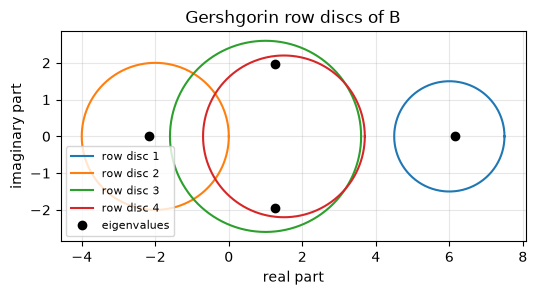

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
t = np.linspace(0, 2 * np.pi, 361)
c, r = gershgorin(B4)
for i in range(4):
    ax.plot(c[i] + r[i] * np.cos(t), r[i] * np.sin(t), label=f"row disc {i + 1}")
lam = np.linalg.eigvals(B4)
ax.plot(lam.real, lam.imag, "ko", label="eigenvalues")
ax.set_aspect("equal")
ax.set_xlabel("real part")
ax.set_ylabel("imaginary part")
ax.set_title("Gershgorin row discs of B")
ax.legend(fontsize=8, loc="lower left")
plt.show()

For $A$ the three discs are disjoint, so each contains one eigenvalue, and
because $A$ is real all three are real. For $B$ the discs around $-2$, $1$ and
$1.5$ form one component containing three eigenvalues, including the complex
pair, and the disc around $6$ contains exactly one.

## 5. Bauer--Fike: normal versus non-normal matrices

[Theorem 9.9](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-thm-bauer-fike) bounds the distance from an eigenvalue of
$A + E$ to the spectrum of $A$ by $\kappa_2(X)\|E\|_2$. We build a normal
matrix $Q\Lambda Q^*$ and a non-normal matrix $X\Lambda X^{-1}$ with the same
eigenvalues and apply random perturbations of norm $\delta = 10^{-8}$.

In [8]:
n = 30
lam = rng.standard_normal(n) + 1j * rng.standard_normal(n)
Qc, _ = np.linalg.qr(rng.standard_normal((n, n)) + 1j * rng.standard_normal((n, n)))
A_normal = Qc @ np.diag(lam) @ Qc.conj().T
X = np.triu(rng.standard_normal((n, n)), 1) + np.eye(n)       # unit upper triangular: non-orthogonal basis
A_nonnormal = X @ np.diag(lam) @ np.linalg.inv(X)

delta = 1e-8
for name, M, kX in [("normal", A_normal, 1.0), ("non-normal", A_nonnormal, np.linalg.cond(X))]:
    worst = 0.0
    for _ in range(20):
        E = rng.standard_normal((n, n)) + 1j * rng.standard_normal((n, n))
        E *= delta / np.linalg.norm(E, 2)
        mu = np.linalg.eigvals(M + E)
        worst = max(worst, np.max(np.min(np.abs(mu[:, None] - lam[None, :]), axis=1)))
    # The computed eigenvalues of M + E are exact for M + E + F with ||F|| = O(n u ||M||), which adds to delta.
    bound = kX * (delta + 100 * n * u * np.linalg.norm(M, 2))
    print(f"{name:10s}: kappa_2(X) = {kX:9.2e}, max distance = {worst:.2e}, "
          f"Bauer-Fike bound = {bound:.2e}, ratio to delta = {worst / delta:.1f}")
    assert worst <= bound

normal    : kappa_2(X) =  1.00e+00, max distance = 2.84e-09, Bauer-Fike bound = 1.00e-08, ratio to delta = 0.3
non-normal: kappa_2(X) =  4.51e+04, max distance = 9.26e-06, Bauer-Fike bound = 5.09e-04, ratio to delta = 925.6


For the normal matrix no eigenvalue moves by more than $\delta$. For the
non-normal matrix the eigenvalues move by much more than $\delta$, but by much
less than the worst-case factor $\kappa_2(X)$: the Bauer--Fike bound is
guaranteed but pessimistic, because it uses one number for all eigenvalues and
all perturbation directions. The individual condition numbers of the next
section are sharper.

## 6. Condition numbers of individual eigenvalues

[Theorem 9.11](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-thm-eig-condition) predicts
$|\lambda(\delta) - \lambda|\approx\delta\,|y^*Ex|/|y^*x|$ for
$\|E\|_2 = \delta$, with the worst case $E = \delta\,yx^*$ giving exactly
$\delta\kappa(\lambda)$. `scipy.linalg.eig(A, left=True)` returns unit left
and right eigenvectors. We use the Frank matrix, whose small eigenvalues are
famously ill conditioned, and the $2\times2$ matrix of
[Example 9.5](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-exa-condition).

In [9]:
def frank(n):
    """Frank matrix: F[i, j] = n - max(i, j) (0-based) for j >= i - 1, zero below the subdiagonal."""
    i, j = np.indices((n, n))
    return np.where(j >= i - 1, n - np.maximum(i, j), 0).astype(float)


def eig_condition(A):
    lam, VL, VR = sla.eig(A, left=True, right=True)
    kappa = 1 / np.abs(np.sum(VL.conj() * VR, axis=0))
    return lam, VL, VR, kappa


A2 = np.array([[1.0, 100.0], [0.0, 2.0]])
print("2x2 example: kappa =", np.round(eig_condition(A2)[3], 4), " sqrt(1 + 100^2) =", round(np.sqrt(1 + 1e4), 4))

F = frank(12)
lam, VL, VR, kappa = eig_condition(F)
order = np.argsort(lam.real)
lam, VL, VR, kappa = lam[order].real, VL[:, order].real, VR[:, order].real, kappa[order]
delta = 1e-12
print(" lambda        kappa     worst-case change/delta   random-E change/delta")
for i in range(len(lam)):
    E = delta * np.outer(VL[:, i], VR[:, i])          # worst case E = delta y x^T
    change_worst = np.min(np.abs(np.linalg.eigvals(F + E) - lam[i]))
    G = rng.standard_normal(F.shape)
    G *= delta / np.linalg.norm(G, 2)
    change_rand = np.min(np.abs(np.linalg.eigvals(F + G) - lam[i]))
    print(f"{lam[i]:9.5f}  {kappa[i]:10.3e}   {change_worst / delta:14.4e}          {change_rand / delta:12.4e}")
    # First-order theory: the worst-case change is delta*kappa up to O(delta^2) terms and rounding
    # errors of order kappa * u * ||F||, which here are below 10 percent of delta * kappa.
    assert abs(change_worst / (delta * kappa[i]) - 1) < 0.1
    assert change_rand <= 1.1 * delta * kappa[i] + kappa[i] * 100 * u * np.linalg.norm(F, 2)

2x2 example: kappa = [100.005 100.005]  sqrt(1 + 100^2) = 100.005
 lambda        kappa     worst-case change/delta   random-E change/delta
  0.03103   1.828e+07       1.8319e+07            2.9798e+06
  0.04951   3.877e+07       3.8766e+07            4.4159e+06
  0.08123   2.665e+07       2.6651e+07            1.3744e+06
  0.14365   6.701e+06       6.6967e+06            6.1564e+05
  0.28475   5.603e+05       5.6014e+05            6.4009e+04
  0.64351   1.447e+04       1.4476e+04            1.9695e+03
  1.55399   2.161e+02       2.1558e+02            5.1685e+00
  3.51186   6.922e+00       6.9327e+00            4.7340e-01
  6.96153   1.711e+00       1.7266e+00            4.2455e-01
 12.31108   3.142e+00       3.1548e+00            6.6436e-01
 20.19899   4.980e+00       5.0164e+00            9.0949e-01
 32.22889   3.287e+00       3.3253e+00            2.6290e-01


The observed worst-case changes match $\delta\kappa(\lambda)$, and random
perturbations of the same norm move each eigenvalue by less. The largest
eigenvalues of the Frank matrix have condition numbers of order one; the
smallest ones have condition numbers above $10^7$, so in double precision their
computed values carry absolute errors of about $\kappa(\lambda)\,u\|F\|_2$,
that is, only about $16 - 7 = 9$ correct digits relative to $\|F\|_2$. This
information is invisible in the eigenvalues themselves, which are all real,
positive and well separated.

## 7. Defective eigenvalues: the $\delta^{1/n}$ law

The eigenvalues of $J_n(0) + \delta e_ne_1^T$ lie on the circle of radius
$\delta^{1/n}$ ([Example 9.7](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-exa-jordan-perturbation)). We check this for
$n = 10$, $\delta = 10^{-10}$, and look at a random perturbation of norm $u$
of $J_{16}(0)$.

In [10]:
n, delta = 10, 1e-10
J = np.diag(np.ones(n - 1), 1)
P = J.copy()
P[-1, 0] = delta
radii = np.abs(np.linalg.eigvals(P))
print(f"n = {n}: |eigenvalues| in [{radii.min():.8f}, {radii.max():.8f}], delta^(1/n) = {delta ** (1 / n):.8f}")
# Rounding errors of size u in P shift the eigenvalues by about u / (n delta^((n-1)/n)) ~ 1e-8 here.
assert np.max(np.abs(radii - delta ** (1 / n))) < 1e-6

# Pseudospectrum: ||(zI - J)^{-1}|| >= |z|^{-n}, so sigma_min(0.1 I - J_10) <= 0.1^10.
smin = np.linalg.svd(0.1 * np.eye(n) - J, compute_uv=False)[-1]
print(f"sigma_min(0.1 I - J_10) = {smin:.3e}  <= 0.1^10 = {0.1 ** 10:.0e}")
assert smin <= 0.1 ** n + 10 * u

n = 16
J16 = np.diag(np.ones(n - 1), 1)
E = rng.standard_normal((n, n))
E *= u / np.linalg.norm(E, 2)
print(f"J_16 + E with ||E||_2 = u: max |eigenvalue| = {np.max(np.abs(np.linalg.eigvals(J16 + E))):.3f}; "
      f"u^(1/16) = {u ** (1 / 16):.4f}")

n = 10: |eigenvalues| in [0.10000000, 0.10000000], delta^(1/n) = 0.10000000
sigma_min(0.1 I - J_10) = 9.900e-11  <= 0.1^10 = 1e-10
J_16 + E with ||E||_2 = u: max |eigenvalue| = 0.091; u^(1/16) = 0.1007


A perturbation at the level of the unit roundoff moves the eigenvalue $0$ of
$J_{16}(0)$ to a distance comparable to $u^{1/16}\approx 0.1$. Defective and
nearly defective eigenvalues can therefore be computed only to a small
fraction of the working precision, whatever the algorithm.

## 8. The Rayleigh quotient: quadratic versus linear accuracy

For a symmetric matrix, [Theorem 9.15](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-thm-rq-quadratic) gives
$|\rho(v) - \lambda_J|\le(\lambda_{\max}-\lambda_{\min})\sin^2\theta$. For a
nonsymmetric matrix only $\mathcal{O}(\sin\theta)$ can be expected. We
perturb an eigenvector by a random direction of size $t$ and fit the slope of
the eigenvalue error against $\sin\theta$ on a log-log scale.

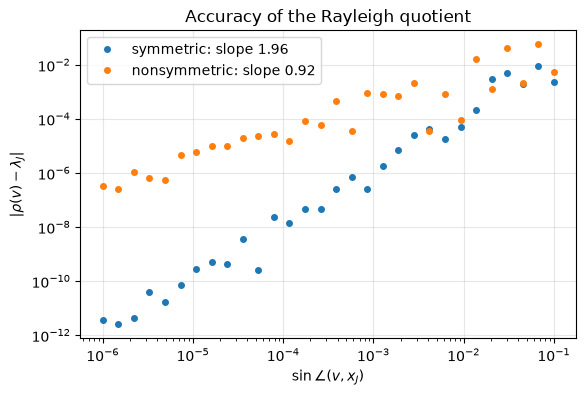

{'symmetric': np.float64(1.962), 'nonsymmetric': np.float64(0.916)}


In [11]:
n = 50
lam50 = np.arange(1.0, n + 1)
A_sym, Q_sym = symmetric_with_eigenvalues(lam50, rng)
X_ns = np.eye(n) + 0.3 * rng.standard_normal((n, n)) / np.sqrt(n)
A_ns = X_ns @ np.diag(lam50) @ np.linalg.inv(X_ns)
J = 24                                                # eigenvalue 25
ts = np.logspace(-1, -6, 30)
slopes = {}
fig, ax = plt.subplots()
for name, M, x in [("symmetric", A_sym, Q_sym[:, J]), ("nonsymmetric", A_ns, X_ns[:, J] / np.linalg.norm(X_ns[:, J]))]:
    s_list, e_list = [], []
    for t in ts:
        d = rng.standard_normal(n)
        d -= x * (x @ d)
        v = x + t * d / np.linalg.norm(d)
        rho = v @ M @ v / (v @ v)
        s_list.append(sin_angle(v, x))
        e_list.append(abs(rho - lam50[J]))
        if name == "symmetric":   # bound of Theorem ch09-thm-rq-quadratic, plus rounding O(n u ||A||)
            assert e_list[-1] <= (lam50[-1] - lam50[0]) * s_list[-1] ** 2 + 10 * n * u * lam50[-1]
    s_arr, e_arr = np.array(s_list), np.array(e_list)
    keep = e_arr > 1e3 * n * u * lam50[-1]            # stay above the rounding level
    slopes[name] = np.polyfit(np.log(s_arr[keep]), np.log(e_arr[keep]), 1)[0]
    ax.loglog(s_arr, e_arr, "o", ms=4, label=f"{name}: slope {slopes[name]:.2f}")
ax.set_xlabel(r"$\sin\angle(v, x_J)$")
ax.set_ylabel(r"$|\rho(v) - \lambda_J|$")
ax.set_title("Accuracy of the Rayleigh quotient")
ax.legend()
plt.show()
print({k: round(v, 3) for k, v in slopes.items()})
assert 1.8 < slopes["symmetric"] < 2.2 and 0.8 < slopes["nonsymmetric"] < 1.2

## 9. Power iteration

We implement [Algorithm 9.1](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-alg-power) with the residual stopping criterion
$\|Av - \rho v\|_2\le\mathrm{tol}\,\|A\|_1$ (the 1-norm is a cheap stand-in
for the 2-norm). The test matrices have the eigenvalues $1$, $0.8$ and 98
further eigenvalues equally spaced in $[-0.7, 0.7]$, as in
[Figure 9.3](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-fig-convergence); one is symmetric and one is nonsymmetric
with the same eigenvalues. Because the eigenpairs are known, we can measure
the true errors.

In [12]:
def power_iteration(A, v0, tol=1e-12, maxit=1000):
    """Power iteration with Rayleigh quotient and residual-based stopping.

    Returns (rho, v, history) where history holds the iterates, Rayleigh quotients and residual norms.
    """
    normA = np.linalg.norm(A, 1)
    v = v0 / np.linalg.norm(v0)
    hist = {"v": [], "rho": [], "res": []}
    for _ in range(maxit):
        w = A @ v
        rho = np.vdot(v, w)                    # Rayleigh quotient, since ||v|| = 1
        res = np.linalg.norm(w - rho * v)
        hist["v"].append(v); hist["rho"].append(rho); hist["res"].append(res)
        if res <= tol * normA:
            break
        v = w / np.linalg.norm(w)
    return rho, v, hist


n = 100
lam = np.concatenate([[1.0, 0.8], np.linspace(-0.7, 0.7, n - 2)])
A, Q = symmetric_with_eigenvalues(lam, rng)
X = np.eye(n) + 0.3 * rng.standard_normal((n, n)) / np.sqrt(n)
B = X @ np.diag(lam) @ np.linalg.inv(X)
x1 = X[:, 0] / np.linalg.norm(X[:, 0])
v0 = rng.standard_normal(n)

rho_A, v_A, hA = power_iteration(A, v0, tol=10 * n * u)
rho_B, v_B, hB = power_iteration(B, v0, tol=10 * n * u)
tanA = np.array([tan_angle(v, Q[:, 0]) for v in hA["v"]])
errA = np.abs(np.array(hA["rho"]) - 1)
tanB = np.array([tan_angle(v, x1) for v in hB["v"]])
errB = np.abs(np.array(hB["rho"]) - 1)
print(f"symmetric:    {len(tanA)} steps, rho = {rho_A:.15f}, final residual {hA['res'][-1]:.1e}")
print(f"nonsymmetric: {len(tanB)} steps, rho = {rho_B:.15f}, final residual {hB['res'][-1]:.1e}")


def observed_factor(e, lo=1e-11, k0=10):
    """Geometric-mean contraction factor over the steps k >= k0 with e_k above lo."""
    idx = [k for k in range(k0, len(e)) if e[k] > lo]
    k1, k2 = idx[0], idx[-1]
    return (e[k2] / e[k1]) ** (1 / (k2 - k1))


# Early steps contain transients from the other eigenvalues, so the factors are measured over later steps.
fac = {"tan, symmetric": observed_factor(tanA, k0=20),
       "eigenvalue, symmetric": observed_factor(errA, lo=1e-13, k0=30),
       "tan, nonsymmetric": observed_factor(tanB, k0=20),
       "eigenvalue, nonsymmetric": observed_factor(errB, lo=1e-13, k0=30)}
for k, v in fac.items():
    print(f"observed factor ({k:25s}) = {v:.4f}")
assert abs(fac["tan, symmetric"] - 0.8) < 0.02 and abs(fac["eigenvalue, symmetric"] - 0.64) < 0.03
assert abs(fac["tan, nonsymmetric"] - 0.8) < 0.02 and abs(fac["eigenvalue, nonsymmetric"] - 0.8) < 0.03
# Theorem ch09-thm-power, checked while the bounds are above the rounding level:
k = np.arange(len(tanA))
bound_tan = tanA[0] * 0.8 ** k
bound_eig = 2 * tanA[0] ** 2 * 0.64 ** k            # max_j |lambda_j - lambda_1| = 1.7 <= 2
ok = bound_tan > 1e-10
assert np.all(tanA[ok] <= bound_tan[ok] * (1 + 1e-8))
ok = bound_eig > 1e-12
assert np.all(errA[ok] <= bound_eig[ok] * (1 + 1e-8))

symmetric:    121 steps, rho = 1.000000000000000, final residual 4.3e-13
nonsymmetric: 126 steps, rho = 0.999999999999991, final residual 3.4e-13
observed factor (tan, symmetric           ) = 0.7997
observed factor (eigenvalue, symmetric    ) = 0.6398
observed factor (tan, nonsymmetric        ) = 0.8000
observed factor (eigenvalue, nonsymmetric ) = 0.7972


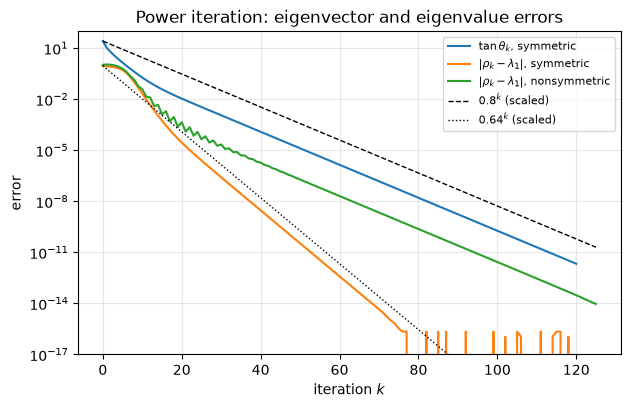

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.semilogy(tanA, label=r"$\tan\theta_k$, symmetric")
ax.semilogy(errA, label=r"$|\rho_k - \lambda_1|$, symmetric")
ax.semilogy(errB, label=r"$|\rho_k - \lambda_1|$, nonsymmetric")
kk = np.arange(max(len(tanA), len(tanB)))
ax.semilogy(kk, tanA[0] * 0.8 ** kk, "k--", lw=1, label=r"$0.8^k$ (scaled)")
ax.semilogy(kk, errA[0] * 0.64 ** kk, "k:", lw=1, label=r"$0.64^k$ (scaled)")
ax.set_ylim(1e-17, 1e2)
ax.set_xlabel("iteration $k$")
ax.set_ylabel("error")
ax.set_title("Power iteration: eigenvector and eigenvalue errors")
ax.legend(fontsize=8)
plt.show()

**Interpretation.** For the symmetric matrix the eigenvector error decreases
with factor $|\lambda_2/\lambda_1| = 0.8$ and the Rayleigh quotient error with
factor $0.64 = 0.8^2$, as [Theorem 9.16](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-thm-power) predicts. For the
nonsymmetric matrix with the same eigenvalues the eigenvector still converges
with factor $0.8$, but the eigenvalue error also decreases only like
$0.8^k$, because the Rayleigh quotient is then only linearly accurate. The
iteration stops on the residual, not on a comparison with known eigenvalues,
so the same code works when the answer is unknown.

**Why not plot successive differences?** If $\lambda_1<0$ the iterates flip
sign in every step. Their angle to the eigenvector still converges, but
$\|v^{(k)} - v^{(k-1)}\|_2$ tends to $2$.

In [14]:
_, _, hneg = power_iteration(-A, v0, tol=10 * n * u)
vs = hneg["v"]
print(f"lambda_1 = -1: final angle tan = {tan_angle(vs[-1], Q[:, 0]):.1e}, "
      f"final ||v_k - v_(k-1)|| = {np.linalg.norm(vs[-1] - vs[-2]):.6f}")
assert tan_angle(vs[-1], Q[:, 0]) < 1e-10 and np.linalg.norm(vs[-1] - vs[-2]) > 1.99

lambda_1 = -1: final angle tan = 2.1e-12, final ||v_k - v_(k-1)|| = 2.000000


## 10. Inverse iteration

[Theorem 9.17](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-thm-inverse) predicts the factor
$|\mu - \lambda_J|/|\mu - \lambda_K|$, with $\lambda_J$ the nearest and
$\lambda_K$ the second nearest eigenvalue to the shift. We factor
$A - \mu I$ once with `scipy.linalg.lu_factor` and reuse it.

In [15]:
def inverse_iteration(A, mu, v0, tol=1e-12, maxit=200):
    """Inverse iteration with a fixed shift; one LU factorization, residual-based stopping."""
    n = A.shape[0]
    normA = np.linalg.norm(A, 1)
    lu_piv = sla.lu_factor(A - mu * np.eye(n))        # (2/3) n^3 flops, once
    v = v0 / np.linalg.norm(v0)
    hist = {"v": [v], "res": []}
    for _ in range(maxit):
        y = sla.lu_solve(lu_piv, v)                   # 2 n^2 flops per step
        v = y / np.linalg.norm(y)
        rho = np.vdot(v, A @ v)
        res = np.linalg.norm(A @ v - rho * v)
        hist["v"].append(v); hist["res"].append(res)
        if res <= tol * normA:
            break
    return rho, v, hist


print("  mu     J-th eigenvalue  predicted factor  observed factor  steps")
for mu in (0.87, 0.95, 0.81):
    d = np.abs(lam - mu)
    Jn, Kn = np.argsort(d)[:2]
    predicted = d[Jn] / d[Kn]
    rho, v, h = inverse_iteration(A, mu, v0, tol=10 * n * u)
    tans = np.array([tan_angle(w, Q[:, Jn]) for w in h["v"]])
    observed = observed_factor(tans, lo=1e-11, k0=3)
    print(f"{mu:5.2f}   {lam[Jn]:8.3f}          {predicted:8.4f}          {observed:8.4f}      {len(h['res'])}")
    assert abs(rho - lam[Jn]) < 100 * n * u        # symmetric: |rho - lambda_J| <= residual (Theorem ch09-thm-residual-bound)
    assert abs(observed - predicted) < 0.1 * predicted + 0.01

  mu     J-th eigenvalue  predicted factor  observed factor  steps


 0.87      0.800            0.5385            0.5270      44
 0.95      1.000            0.3333            0.3244      25
 0.81      0.800            0.0909            0.0774      11


The observed factors agree with the predicted ones. A shift close to an
eigenvalue gives very fast convergence, at the price of one factorization per
shift.

### The nearly singular solve is harmless

Now take a shift within $10^{-12}$ of an eigenvalue. The matrix $A - \mu I$
has condition number of order $10^{12}$ or more, and the computed solution
$\hat y$ may have a large relative error. Yet its direction is excellent:
[Proposition 9.6](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-prop-inverse-residual) bounds the residual of
$\hat v = \hat y/\|\hat y\|_2$ by $1/\|\hat y\|_2 + \|F\|_2$.

In [16]:
n = 50
A50, Q50 = symmetric_with_eigenvalues(np.arange(1.0, n + 1), rng)
mu = 25 + 1e-12
v = rng.standard_normal(n)
v /= np.linalg.norm(v)
M = A50 - mu * np.eye(n)
y_lu = sla.lu_solve(sla.lu_factor(M), v)
y_sym = sla.solve(M, v, assume_a="sym")                # a different backward stable method
v_hat = y_lu / np.linalg.norm(y_lu)
res = np.linalg.norm(A50 @ v_hat - mu * v_hat)
gap = np.min(np.abs(np.delete(np.arange(1.0, n + 1), 24) - mu))
print(f"cond(A - mu I)                     = {np.linalg.cond(M):.1e}")
print(f"||y_hat||                          = {np.linalg.norm(y_lu):.1e}")
print(f"relative difference of two solves  = {np.linalg.norm(y_lu - y_sym) / np.linalg.norm(y_sym):.1e}")
print(f"sin angle(y_hat, q_25)             = {sin_angle(y_lu, Q50[:, 24]):.1e}")
print(f"residual ||A v - mu v||            = {res:.1e}  (1/||y_hat|| = {1 / np.linalg.norm(y_lu):.1e})")
# Proposition ch09-prop-inverse-residual with ||F|| = O(n u ||A||) for a backward stable solve:
assert res <= 1 / np.linalg.norm(y_lu) + 100 * n * u * np.linalg.norm(A50, 2)
# Theorem ch09-thm-sin-theta-vector: sin angle <= residual / gap (gap ~ 1 here).
assert sin_angle(y_lu, Q50[:, 24]) <= res / gap * (1 + 1e-6) + 10 * u

cond(A - mu I)                     = 2.5e+13
||y_hat||                          = 1.9e+11
relative difference of two solves  = 3.9e-04
sin angle(y_hat, q_25)             = 1.7e-12
residual ||A v - mu v||            = 5.3e-12  (1/||y_hat|| = 5.3e-12)


The two solutions differ by a relative amount far above $u$ (of the order
of $\kappa(A-\mu I)u$), but both are huge multiples of nearly the same
vector: the error lies almost entirely along $q_{25}$, which is the direction
we want. One step of inverse iteration with this shift already produces an
eigenvector whose angle to $q_{25}$ is of the order of $|\mu - 25| = 10^{-12}$,
exactly as the residual bound predicts.

## 11. Rayleigh quotient iteration and its order of convergence

We implement [Algorithm 9.3](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-alg-rqi) with the residual stopping criterion.
The history records the Rayleigh quotients, the residual norms and the
iterates, so that we can measure the error and estimate the order with
$q_k = \log(e_{k+1}/e_k)/\log(e_k/e_{k-1})$ ([(9.19)](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#equation-ch09-eq-order)).

In [17]:
def rqi(A, v0, tol=1e-12, maxit=50):
    """Rayleigh quotient iteration with residual-based stopping; returns (rho, v, history)."""
    n = A.shape[0]
    normA = np.linalg.norm(A, 1)
    v = v0 / np.linalg.norm(v0)
    hist = {"v": [], "rho": [], "res": []}
    for _ in range(maxit):
        rho = np.vdot(v, A @ v)
        res = np.linalg.norm(A @ v - rho * v)
        hist["v"].append(v); hist["rho"].append(rho); hist["res"].append(res)
        if res <= tol * normA:
            break
        y = np.linalg.solve(A - rho * np.eye(n), v)   # a new factorization in every step
        v = y / np.linalg.norm(y)
    return rho, v, hist


n = 50
J = 24
d = rng.standard_normal(n)
d -= Q_sym[:, J] * (Q_sym[:, J] @ d)
v0 = Q_sym[:, J] + 0.4 * d / np.linalg.norm(d)
rho, v, h = rqi(A_sym, v0, tol=10 * n * u)
Jfound = np.argmin(np.abs(lam50 - rho))
e = np.array([sin_angle(w, Q_sym[:, Jfound]) for w in h["v"]])
print(f"converged to lambda = {rho:.15f} (eigenvalue {lam50[Jfound]:.0f}) in {len(e) - 1} steps")
print(" k   residual     sin(angle)   order estimate")
for k in range(len(e)):
    q = np.log(e[k] / e[k - 1]) / np.log(e[k - 1] / e[k - 2]) if 2 <= k and e[k] > 1e3 * u else np.nan
    print(f"{k:2d}   {h['res'][k]:.2e}    {e[k]:.2e}     {q:.2f}")
assert abs(rho - lam50[Jfound]) <= h["res"][-1] + 10 * n * u * lam50[-1]

converged to lambda = 25.000000000000007 (eigenvalue 25) in 3 steps
 k   residual     sin(angle)   order estimate
 0   5.28e+00    3.71e-01     nan
 1   2.05e-02    4.93e-03     nan
 2   7.39e-08    5.59e-08     2.63
 3   1.09e-14    3.87e-15     nan


A single run gives only one or two usable order estimates before the error
reaches the rounding level, and they depend on the constant in
$e_{k+1}\approx Ce_k^3$. A more reliable measurement looks at the one-step
map: start from many vectors at distance $e$ from an eigenvector, take one
step, and fit $\log e_{\text{next}}$ against $\log e$.

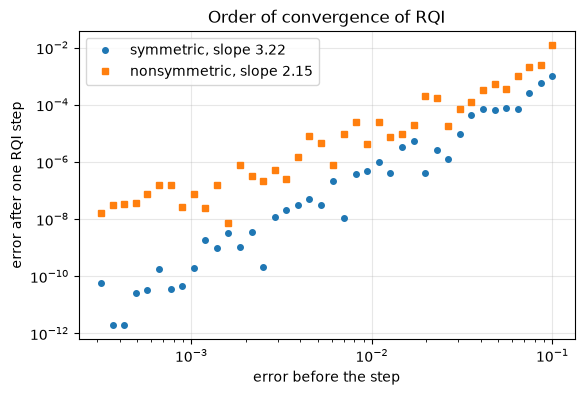

fitted order: symmetric 3.22, nonsymmetric 2.15


In [18]:
def one_step_slope(M, x, ts):
    e0, e1 = [], []
    for t in ts:
        d = rng.standard_normal(len(x))
        d -= x * (x @ d)
        w = x + t * d / np.linalg.norm(d)
        w /= np.linalg.norm(w)
        rho = w @ M @ w
        y = np.linalg.solve(M - rho * np.eye(len(x)), w)
        e0.append(sin_angle(w, x)); e1.append(sin_angle(y, x))
    e0, e1 = np.array(e0), np.array(e1)
    keep = e1 > 1e-12                                  # above the rounding level
    return np.polyfit(np.log(e0[keep]), np.log(e1[keep]), 1)[0], e0, e1


ts = np.logspace(-3.5, -1, 40)
slope_sym, e0s, e1s = one_step_slope(A_sym, Q_sym[:, J], ts)
slope_ns, e0n, e1n = one_step_slope(A_ns, X_ns[:, J] / np.linalg.norm(X_ns[:, J]), ts)
fig, ax = plt.subplots()
ax.loglog(e0s, e1s, "o", ms=4, label=f"symmetric, slope {slope_sym:.2f}")
ax.loglog(e0n, e1n, "s", ms=4, label=f"nonsymmetric, slope {slope_ns:.2f}")
ax.set_xlabel("error before the step")
ax.set_ylabel("error after one RQI step")
ax.set_title("Order of convergence of RQI")
ax.legend()
plt.show()
print(f"fitted order: symmetric {slope_sym:.2f}, nonsymmetric {slope_ns:.2f}")
assert 2.6 < slope_sym < 3.4 and 1.7 < slope_ns < 2.3

**Interpretation.** For the symmetric matrix the error after one step behaves
like the cube of the error before it ([Theorem 9.18](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-thm-rqi)); for the
nonsymmetric matrix like the square, because its Rayleigh quotient is only
linearly accurate (Parlett, 1974). In both cases the iteration stops on
the residual, and a final residual of order $u\|A\|$ means that the computed
pair is an exact eigenpair of a matrix within that distance of $A$
([Proposition 9.4](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-prop-backward-error)).

## 12. Simultaneous iteration

We implement [Algorithm 9.4](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-alg-subspace) for $p = 3$ on a symmetric matrix
with eigenvalues $1, 0.95, 0.9, 0.6$ and 96 further ones in $[-0.5, 0.5]$. The
subspace should converge with factor $|\lambda_4/\lambda_3| = 2/3$, even
though $|\lambda_2/\lambda_1| = 0.95$ makes power iteration for the first
eigenvector slow. The tangent of the largest principal angle is
$\|Q_2^TZ(Q_1^TZ)^{-1}\|_2$, as in the proof of [Theorem 9.19](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-thm-subspace).

68 steps; Ritz values [1.   0.95 0.9 ]; true [1.   0.95 0.9 ]
observed subspace factor 0.6455, predicted 0.6667
final tan angle of the first column to q_1: 1.91e-01


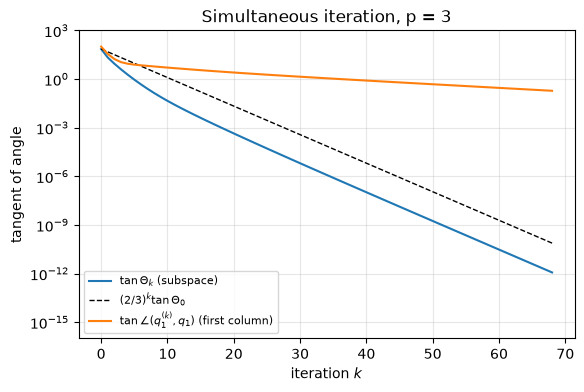

In [19]:
def subspace_iteration(A, Q0, tol=1e-12, maxit=500):
    """Simultaneous iteration with Rayleigh-Ritz; returns Q, the Ritz values and the history of Q's."""
    normA = np.linalg.norm(A, 1)
    Z = A @ Q0
    history = []
    for _ in range(maxit):
        Q, _ = np.linalg.qr(Z)                    # thin Householder QR with explicit Q, about 4 n p^2 flops
        Z = A @ Q                                 # 2 n^2 p flops, reused in the next step
        Bk = Q.T @ Z                              # Rayleigh-Ritz matrix
        history.append(Q)
        if np.linalg.norm(Z - Q @ Bk, "fro") <= tol * normA:
            break
    return Q, np.sort(np.linalg.eigvalsh((Bk + Bk.T) / 2))[::-1], history


n, p = 100, 3
lam_s = np.concatenate([[1.0, 0.95, 0.9, 0.6], np.linspace(-0.5, 0.5, n - 4)])
A_s, Q_s = symmetric_with_eigenvalues(lam_s, rng)
Q1, Q2 = Q_s[:, :p], Q_s[:, p:]
Q0, _ = np.linalg.qr(rng.standard_normal((n, p)))
Qp, ritz, history = subspace_iteration(A_s, Q0, tol=10 * n * u)
tanTheta = np.array([np.linalg.norm(Q2.T @ Qk @ np.linalg.inv(Q1.T @ Qk), 2) for Qk in [Q0] + history])
col1 = np.array([tan_angle(Qk[:, 0], Q_s[:, 0]) for Qk in [Q0] + history])
print(f"{len(history)} steps; Ritz values {np.round(ritz, 12)}; true {lam_s[:p]}")
print(f"observed subspace factor {observed_factor(tanTheta, lo=1e-11, k0=5):.4f}, predicted {0.6 / 0.9:.4f}")
print(f"final tan angle of the first column to q_1: {col1[-1]:.2e}")
k = np.arange(len(tanTheta))
ok = tanTheta[0] * (2 / 3) ** k > 1e-10
assert np.all(tanTheta[ok] <= tanTheta[0] * (2 / 3) ** k[ok] * (1 + 1e-8))   # Theorem ch09-thm-subspace
assert np.max(np.abs(ritz - lam_s[:p])) < 100 * n * u

fig, ax = plt.subplots()
ax.semilogy(k, tanTheta, label=r"$\tan\Theta_k$ (subspace)")
ax.semilogy(k, tanTheta[0] * (2 / 3) ** k, "k--", lw=1, label=r"$(2/3)^k \tan\Theta_0$")
ax.semilogy(k, col1, label=r"$\tan\angle(q^{(k)}_1, q_1)$ (first column)")
ax.set_ylim(1e-16, 1e3)
ax.set_xlabel("iteration $k$")
ax.set_ylabel("tangent of angle")
ax.set_title("Simultaneous iteration, p = 3")
ax.legend(fontsize=8)
plt.show()

The subspace converges at the predicted rate (the bound is an upper bound,
and the observed factor is slightly smaller). The first column of $Q^{(k)}$ is
exactly the power iteration vector, so it converges only with factor $0.95$
and is still far from $q_1$ when the iteration stops. The Rayleigh--Ritz step
does not need it: once the subspace is accurate, the eigenvalues of the
$3\times3$ matrix $Q^{(k)T}AQ^{(k)}$ are accurate, which is why the Ritz
values agree with the true eigenvalues to working precision.

**Bridge to the QR algorithm.** With $p = n$ and $Q^{(0)} = I$, the matrices
$Q^{(k)T}AQ^{(k)}$ of simultaneous iteration coincide, up to signs, with the
iterates $A^{(k)} = R^{(k)}Q^{(k)}$ of the unshifted QR algorithm of
[Chapter 10](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10). We check this for a few steps.

In [20]:
n = 6
A6, _ = symmetric_with_eigenvalues(np.array([6.0, 5.0, 4.0, 3.0, 2.0, 1.0]), rng)
Qk = np.eye(n)
Ak = A6.copy()
for _ in range(5):
    Qk, _ = np.linalg.qr(A6 @ Qk)                 # simultaneous iteration with p = n
    Qqr, Rqr = np.linalg.qr(Ak)                   # unshifted QR algorithm
    Ak = Rqr @ Qqr
A_sim = Qk.T @ A6 @ Qk
print("max | |A_sim| - |A_qr| | =", np.max(np.abs(np.abs(A_sim) - np.abs(Ak))))
# Both are orthogonal similarity transforms computed stably; they agree up to diagonal sign changes,
# with differences of order (number of steps) * n u ||A||.
assert np.allclose(np.abs(A_sim), np.abs(Ak), atol=100 * n * u * np.linalg.norm(A6, 2))

max | |A_sim| - |A_qr| | = 2.6645352591003757e-15


## Common mistakes

- Reading the diagonal of a real Schur form as the eigenvalues (Section 3).
- Computing eigenvalues from the coefficients of the characteristic
  polynomial (Section 2).
- Stopping an iteration by comparing with eigenvalues computed by another
  program. The comparison presupposes the answer; use the residual, which is
  the backward error.
- Plotting $\|v^{(k)} - v^{(k-1)}\|$ as "the error", which hides the true
  constant and fails completely when $\lambda_1<0$ (Section 9).
- Writing the inverse iteration factor upside down: it is
  $|\mu - \lambda_J|/|\mu - \lambda_K|<1$, nearest over second nearest.
- Claiming cubic convergence of RQI without measuring it, or expecting it for
  nonsymmetric matrices (Section 11).
- Believing that a tiny residual guarantees an accurate eigenvalue of a
  non-normal matrix (Sections 6 and 7).
- Using `np.random.seed`, or reseeding inside a loop. Use one
  `np.random.default_rng` generator for the whole notebook.

## Your turn

1. Compute Gershgorin discs of $D^{-1}AD$ for a diagonal $D$ of your choice
   and find a scaling that isolates each eigenvalue of the matrix $A$ of
   [Exercise 9.4](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-ex-gershgorin-scaling).
2. Repeat Section 5 with $X$ replaced by $I + sN$ for a strictly upper
   triangular random $N$ and $s = 0.1, 1, 10$. Plot the maximal eigenvalue
   movement against $\kappa_2(X)$.
3. Apply RQI to a normal but nonsymmetric matrix $Q\Lambda Q^*$ with complex
   $\Lambda$ and measure the order ([Exercise 9.12](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-ex-rqi-order)).
4. Implement a two-sided RQI that also iterates on an approximate left
   eigenvector and uses the shift $y^*Ax/y^*x$; measure its order on the
   nonsymmetric matrix of Section 11 ([Exercise 9.9](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09-ex-two-sided)).
5. Use power iteration on $A^TA$, without forming it, to estimate $\|A\|_2$
   for a $300\times200$ random matrix, and compare the convergence with
   $(\sigma_2/\sigma_1)^{2k}$.

## Key takeaways

- Eigenvalue solvers are iterative; the characteristic polynomial is a
  mathematically correct but numerically poor representation.
- Normal matrices have perfectly conditioned eigenvalues; for non-normal
  matrices the condition number $1/|y^*x|$ of each eigenvalue, and the
  pseudospectra, show how far eigenvalues can move, and defective eigenvalues
  move like $\delta^{1/n}$.
- The residual of an approximate eigenpair is its backward error and the
  right stopping criterion.
- Power iteration converges with factor $|\lambda_2/\lambda_1|$ (squared for
  the symmetric Rayleigh quotient), inverse iteration with factor
  $|\mu-\lambda_J|/|\mu-\lambda_K|$, and RQI cubically for symmetric and
  quadratically for general matrices; all these rates can be measured.
- Simultaneous iteration converges on subspaces and is the unshifted QR
  algorithm in disguise.

## Further reading

Trefethen and Bau (1997), Lectures 24--28; Golub and Van Loan (2013), Sections
7.1--7.3 and 8.1--8.2; Parlett (1998), Chapter 4, for Rayleigh quotient
iteration; Trefethen and Embree (2005) for pseudospectra.